In [17]:
from few.utils.Extra_for_project.flux_calculations import compare, kerrecceqA, nex
from few.utils.geodesic import get_separatrix
import numpy as np
import matplotlib.pyplot as plt
from few.utils.mappings.kerrecceq import DELTAPMAX_REGIONC,DELTAPMIN_REGIONC


def rem_sing(p,pdots,threshold):
    to_rm = []
    for i,pdot in enumerate(pdots):
        if np.abs(pdot) > threshold:
            to_rm.append(i)

    p_cleaned, pdots_cleaned = np.delete(p,to_rm), np.delete(pdots,to_rm)

    return p_cleaned, pdots_cleaned

## Plot edots and pdots for few and nex to see differnece

Text(0.5, 1.0, 'edots')

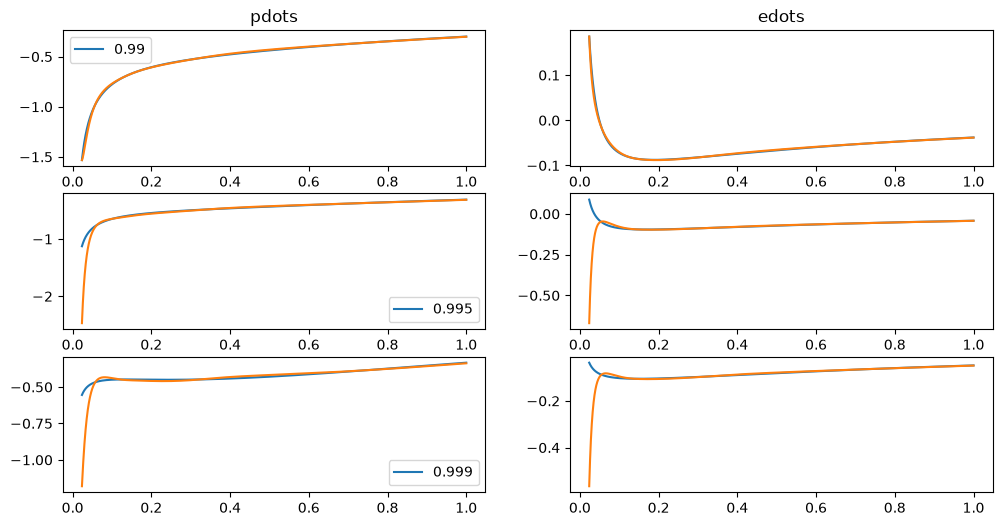

In [2]:
fig, axs = plt.subplots(3,2,figsize = (12,6))
a_vals = [0.99,0.995,0.999]

for i,aa in enumerate(a_vals):
    pdots_nex,pdots,edots_nex,edots,p,psep = compare(0.2,aa)

    axs[i,0].plot(p-psep, pdots, label = f"{aa}")
    axs[i,0].plot(p-psep, pdots_nex, label = f"")
    axs[i,1].plot(p-psep, edots, label = f"{aa}")
    axs[i,1].plot(p-psep, edots_nex, label = f"")

    axs[i,0].legend()

    
axs[0,0].set_title(r"pdots")
axs[0,1].set_title(r"edots")

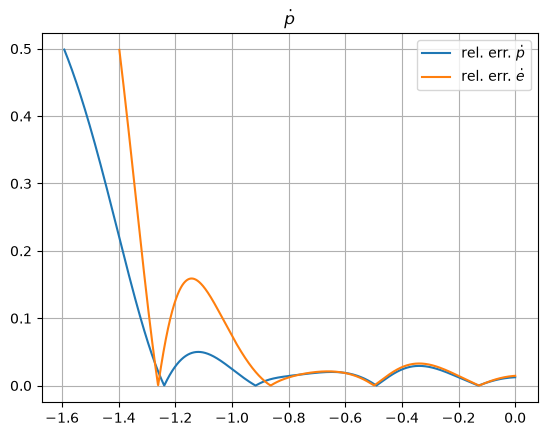

In [14]:
pdotsA,pdotsB,edotsA,edotsB,p,psep = compare(0.2,0.999)

#plt.plot(p-psep,np.abs((pdotsA-pdotsB)/pdotsA),label = r"$\left|\frac{nex - few}{nex}\right|$")

#plt.plot(p-psep,pdotsB,label = "KerrEccEqFlux")
#plt.plot(p-psep,pdotsA,label = "NEX")

e_sym_diff = 2*np.abs(edotsA-edotsB)/(np.abs(edotsA)+np.abs(edotsB))
p_sym_diff = 2*np.abs(pdotsA-pdotsB)/(np.abs(pdotsA)+np.abs(pdotsB))

e_rel_diff = np.abs(edotsA-edotsB)/np.abs(edotsA)
p_rel_diff = np.abs(pdotsA-pdotsB)/np.abs(pdotsA)

#Remove points that are defintie singularities:
p1,p_rel_diff_clean = rem_sing(p,p_rel_diff,0.5)
p2,e_rel_diff_clean = rem_sing(p,e_rel_diff,0.5)


plt.plot(np.log10(p1-psep) , p_rel_diff_clean,label = r"rel. err. $\dot{p}$")
plt.plot(np.log10(p2-psep) , e_rel_diff_clean,label = r"rel. err. $\dot{e}$")

plt.legend()
plt.title(r"$\dot{p}$")
plt.grid()

#plt.ylim(-0,-00.05)
#plt.xlim(0,6*DELTAPMIN_REGIONC)


Text(0, 0.5, '$\\dot{e}$')

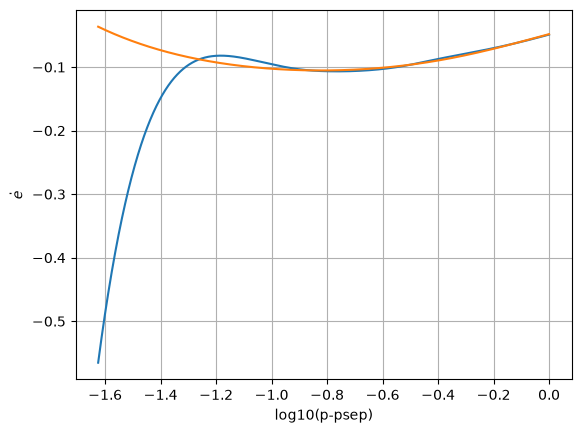

In [15]:
plt.plot(np.log10(p-psep),edotsA)
plt.plot(np.log10(p-psep),edotsB)
plt.grid()
plt.xlabel(r"log10(p-psep)")
plt.ylabel(r"$\dot{e}$")

Text(0.5, 0.98, 'Relative errors in all fluxes. (With normalisation by PN terms)')

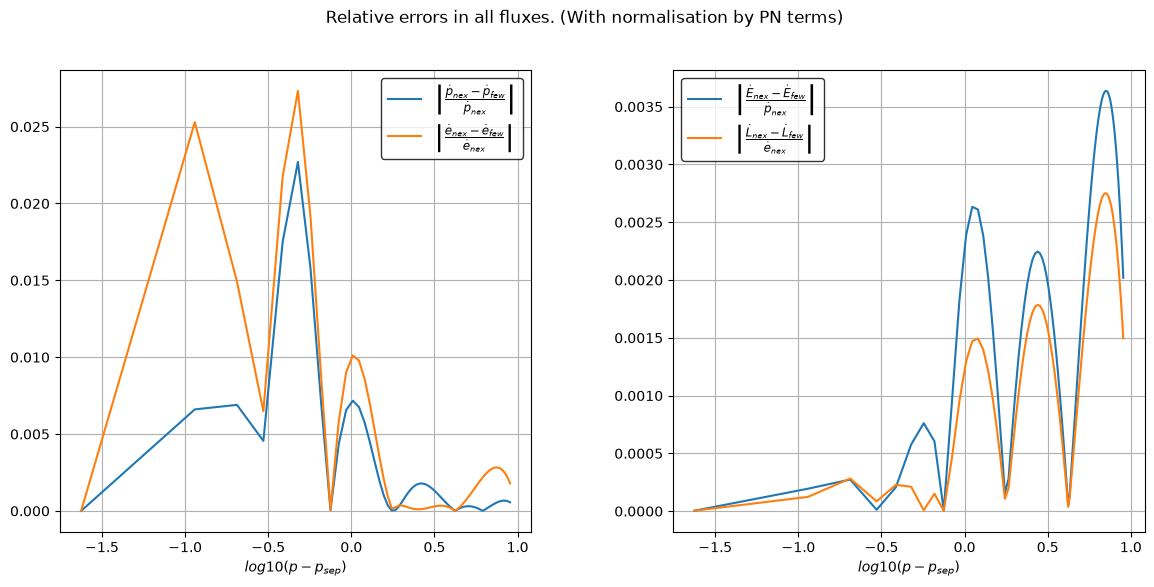

In [19]:
a,e,x = 0.99,0.1,1
pLSO = get_separatrix(a,e,x)


p = np.linspace(pLSO+DELTAPMIN_REGIONC, pLSO+9.001,100)  #Evaluate on a smaller grid to avoid singularities

fig, axs = plt.subplots(1,2)
plt.subplots_adjust(wspace=0.3)
fig.set_size_inches(14, 6)


pdot_rel_error = np.abs(( nex(a,p,e,x)[2]-kerrecceqA(a,p,e,x)[2])/nex(a,p,e,x)[2])
edot_rel_error = np.abs(( nex(a,p,e,x)[3]-kerrecceqA(a,p,e,x)[3])/kerrecceqA(a,p,e,x)[3])   
Edot_rel_error = np.abs(( nex(a,p,e,x)[0]-kerrecceqA(a,p,e,x)[0])/nex(a,p,e,x)[0])
Ldot_rel_error = np.abs(( nex(a,p,e,x)[1]-kerrecceqA(a,p,e,x)[1])/nex(a,p,e,x)[1])
#print(kerrecceqA(a,p,e,x)[3])
#print(nex(a,p,e,x)[3])

axs[0].plot(np.log10(p-pLSO),pdot_rel_error,label=r"$\left|\frac{\dot{p}_{nex} - \dot{p}_{few}}{\dot{p}_{nex}}\right|$")
axs[0].plot(np.log10(p-pLSO),edot_rel_error,label=r"$\left|\frac{\dot{e}_{nex} - \dot{e}_{few}}{\dot{e}_{nex}}\right|$")

axs[0].legend(fontsize = "large",edgecolor = "black")
axs[0].grid()
axs[0].set_xlabel(r"$log10(p-p_{sep})$")


axs[1].plot(np.log10(p-pLSO),Edot_rel_error,label=r"$\left|\frac{\dot{E}_{nex} - \dot{E}_{few}}{\dot{p}_{nex}}\right|$")
axs[1].plot(np.log10(p-pLSO),Ldot_rel_error,label=r"$\left|\frac{\dot{L}_{nex} - \dot{L}_{few}}{\dot{e}_{nex}}\right|$")

axs[1].legend(fontsize = "large",edgecolor = "black")
axs[1].grid()
axs[1].set_xlabel(r"$log10(p-p_{sep})$")
fig.suptitle("Relative errors in all fluxes. (With normalisation by PN terms)")

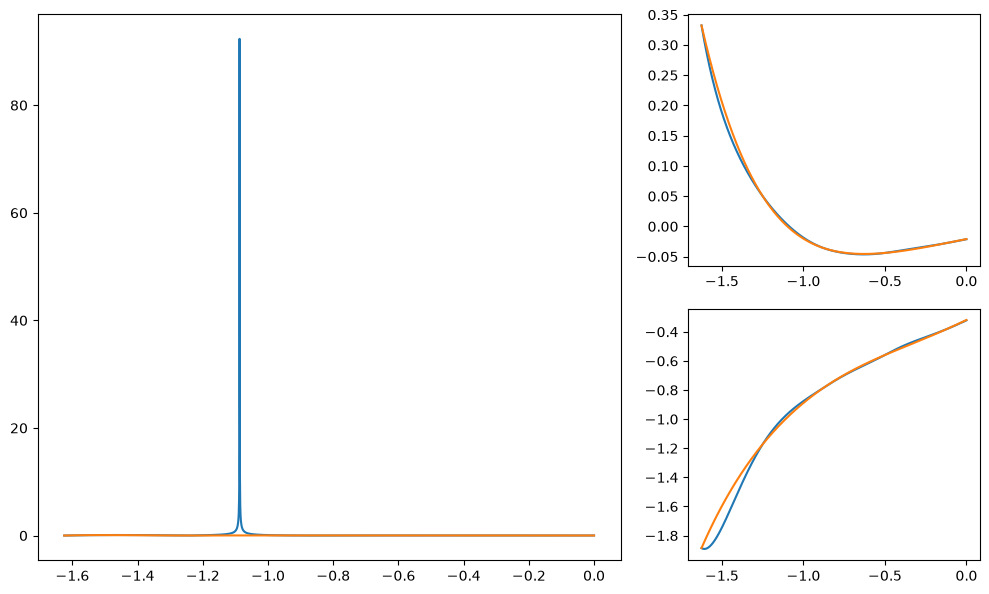

In [21]:
e,a = 0.1,0.99
pdot,pdot_nex,edot,edot_nex,p,psep= compare(e,a)

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Large plot on the left
ax_main = fig.add_subplot(gs[:, 0])

# Two smaller plots on the right
ax_top = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, 1])

ax_main.plot(np.log10(p-psep),np.abs((edot-edot_nex)/edot))
ax_main.plot(np.log10(p-psep),np.abs((pdot-pdot_nex)/pdot))
ax_top.plot(np.log10(p-psep),edot)
ax_top.plot(np.log10(p-psep),edot_nex)
ax_bottom.plot(np.log10(p-psep),pdot)
ax_bottom.plot(np.log10(p-psep),pdot_nex)

plt.tight_layout()
plt.show()